# 01 — Datos y hallazgos del análisis exploratorio

Extractos seudonimizados de Ford Argentina: **ventas Ranger 2024-2026** (`ranger_sales_arg_2024_2026.csv`, una fila por
vehículo vendido) y **Agenda Ford 2024-2026** (`ranger_service_agenda_arg_2024_2026 1.csv`, una fila por ítem de servicio
dentro de un turno, todo el parque Ranger). Los datos crudos son solo lectura; acá se leen los parquet tipados de
`data/interim/` (generados por `src/repurchase/io.py`).

El análisis completo, con scripts reproducibles y verificación independiente, está en `reports/eda/` y en
`docs/01_hallazgos_eda.md`. Este notebook muestra lo esencial.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)
from IPython.display import Image, Markdown, display
from repurchase import config
from repurchase.eventos import appointments, CUTOFF
from repurchase.io import load_sales, load_agenda
print("cutoff de datos:", CUTOFF.date())

cutoff de datos: 2026-08-25


## 1. Tamaño y grano de las tablas

In [2]:
sales = load_sales(); agenda = load_agenda(); appt = appointments(agenda)
print(f"ventas: {len(sales):,} vehículos, {sales.customer_id.nunique():,} clientes, {sales.SalesDate.min().date()} → {sales.SalesDate.max().date()}")
print(f"agenda: {len(agenda):,} ítems, {appt.shape[0]:,} turnos, {agenda.vehicle_id.nunique():,} vehículos, {agenda.dealer_id.nunique()} concesionarios")
print("estado de los turnos:"); display(appt.StatusARG.value_counts().to_frame("turnos"))
print("mantenimientos programados completados:", int(appt.is_completed_maintenance.sum()))

ventas: 59,384 vehículos, 45,959 clientes, 2024-01-01 → 2026-08-24
agenda: 631,623 ítems, 492,442 turnos, 111,752 vehículos, 95 concesionarios
estado de los turnos:


,turnos
StatusARG,
(60) Concluido,342691
(70) Cancelado,101222
(80) No asistio,27237
(90) Concluido sin OS,15507
(30) Agendado,3953
(40) En progreso,1832


mantenimientos programados completados: 222889


## 2. La regla de mantenimiento real: por kilómetros y distinta por generación

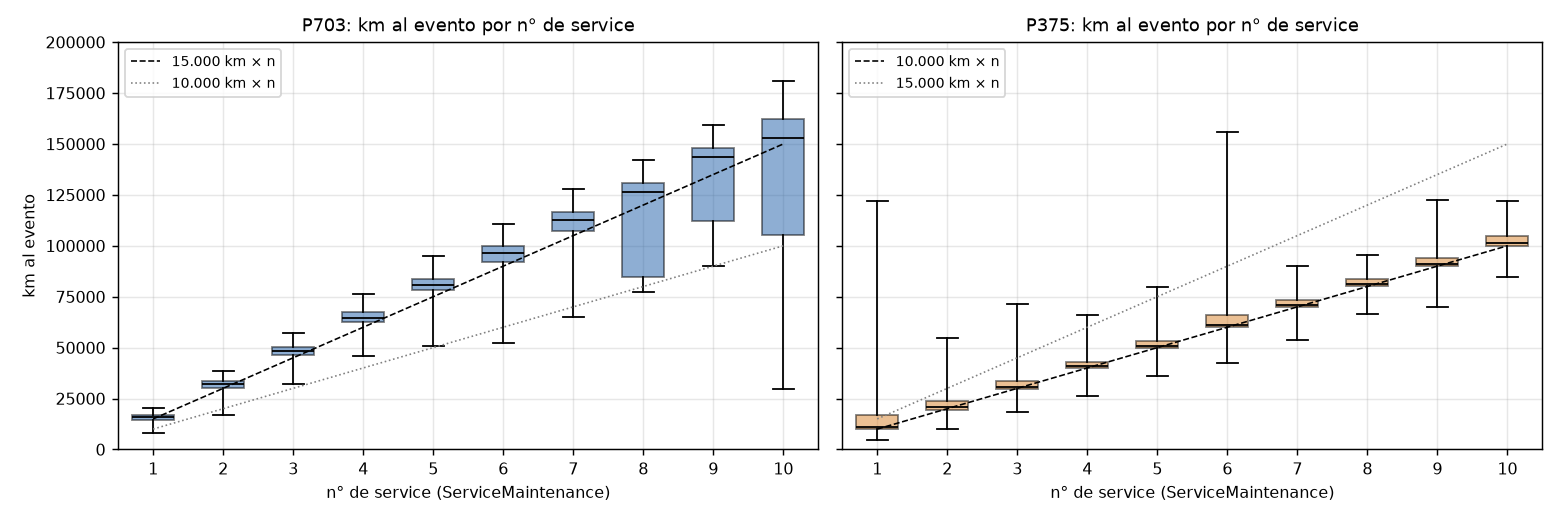

*Km al n-ésimo service: P703 sigue 15.000 × n; P375 sigue 10.000 × n. El plan es por km, no anual.*

In [3]:
display(Image(filename=str(ROOT / "reports/figures/eda/02_cadencia_ventana_box_km_por_service.png"), width=900)); display(Markdown("*Km al n-ésimo service: P703 sigue 15.000 × n; P375 sigue 10.000 × n. El plan es por km, no anual.*"))

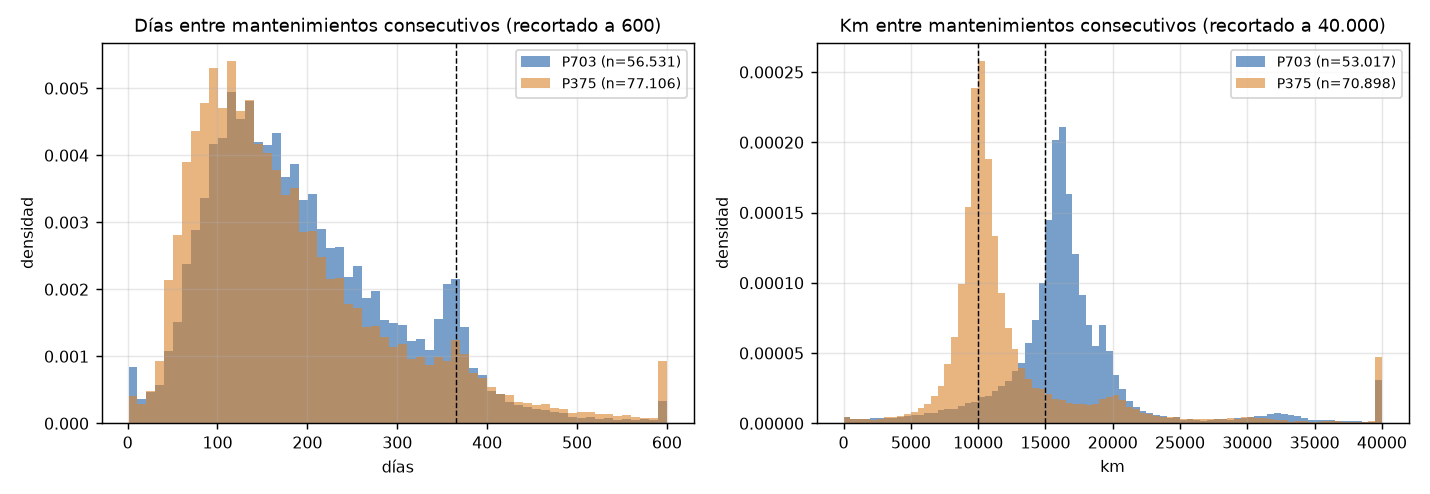

*Días y km entre mantenimientos consecutivos: mediana 161 días; km bimodal (10.300 P375 / 16.200 P703).*

In [4]:
display(Image(filename=str(ROOT / "reports/figures/eda/02_cadencia_ventana_hist_intervalos.png"), width=900)); display(Markdown("*Días y km entre mantenimientos consecutivos: mediana 161 días; km bimodal (10.300 P375 / 16.200 P703).*"))

## 3. La columna `KM` es una foto por vehículo, no el km del turno (leakage)

In [5]:
g = agenda.groupby("vehicle_id").agg(km_unicos=("KM", "nunique"), vck_unicos=("VehicleCurrentKM", "nunique"), turnos=("schedule_id", "nunique"))
print("vehículos con un único valor de KM en todos sus turnos:", f"{(g.km_unicos <= 1).mean():.2%}")
print("vehículos con ≥2 turnos y más de un VehicleCurrentKM:", f"{(g[g.turnos >= 2].vck_unicos > 1).mean():.2%}")

vehículos con un único valor de KM en todos sus turnos: 99.99%
vehículos con ≥2 turnos y más de un VehicleCurrentKM: 86.69%


## 4. Retención por edad del vehículo y tasa base de churn

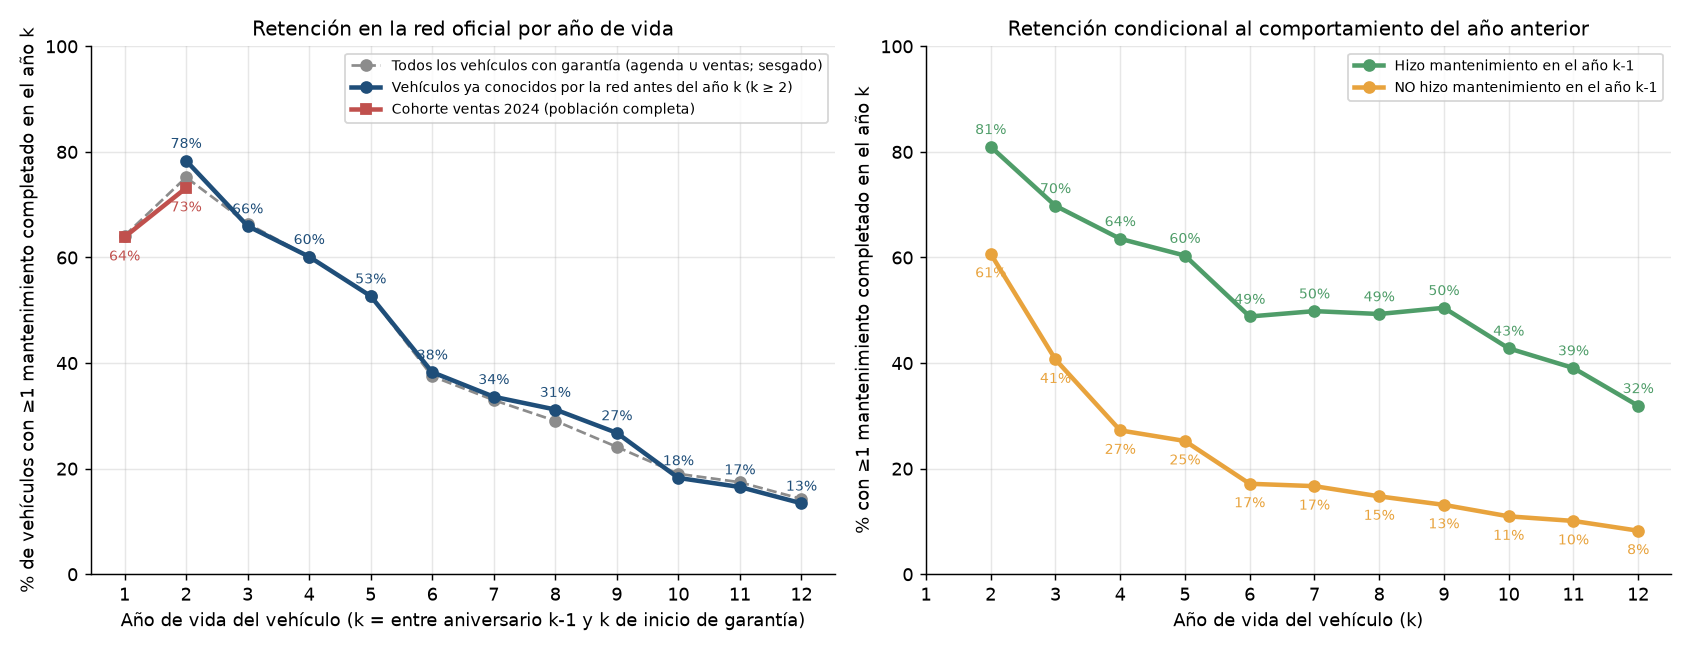

*Curva de retención por año de vida del vehículo.*

In [6]:
display(Image(filename=str(ROOT / "reports/figures/eda/03_retencion_churn_curva_edad.png"), width=900)); display(Markdown("*Curva de retención por año de vida del vehículo.*"))

## 5. Cohorte de ventas 2024: primer service

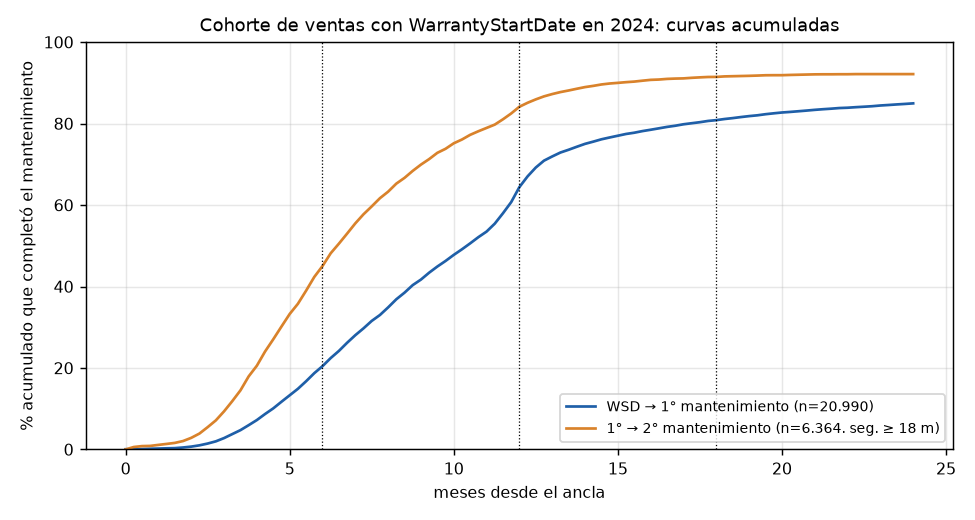

*64,5 % hizo el 1° service en la red dentro de 12 meses; 80,9 % en 18. El mayor churn está en la primera ventana.*

In [7]:
display(Image(filename=str(ROOT / "reports/figures/eda/02_cadencia_ventana_cohorte2024_curvas.png"), width=900)); display(Markdown("*64,5 % hizo el 1° service en la red dentro de 12 meses; 80,9 % en 18. El mayor churn está en la primera ventana.*"))

## 6. Sensibilidad de la ventana

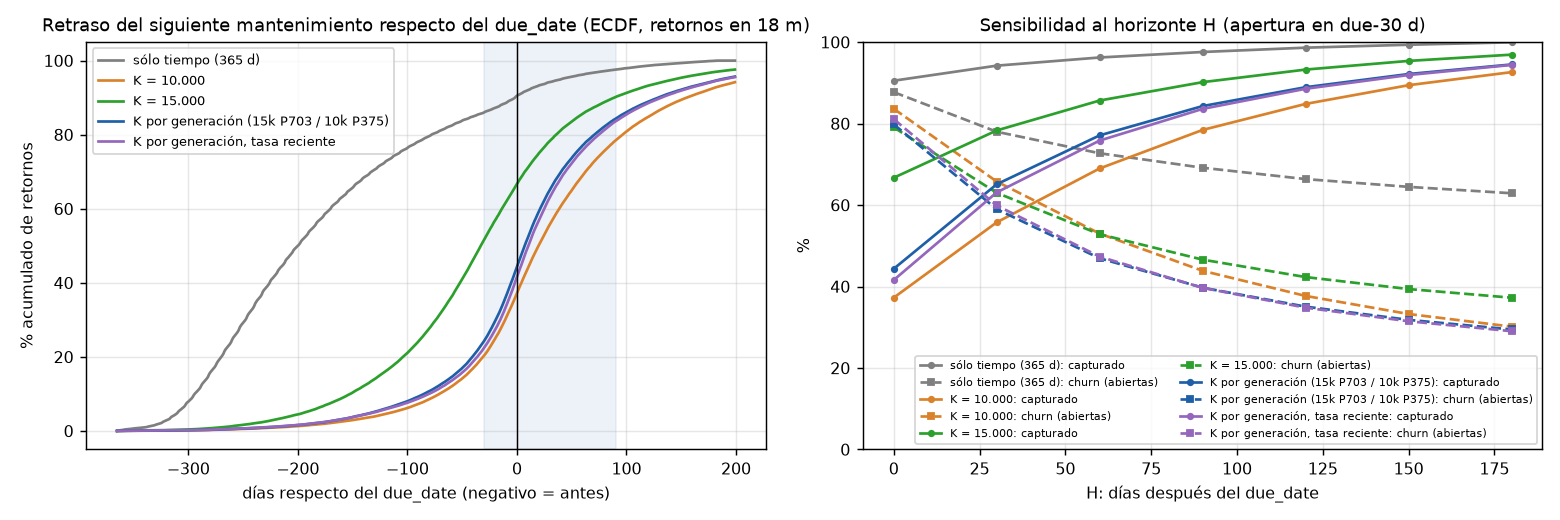

*Retraso real del retorno respecto del vencimiento estimado, según regla. La regla 'solo tiempo' queda 200 días tarde.*

In [8]:
display(Image(filename=str(ROOT / "reports/figures/eda/02_cadencia_ventana_ventana_retraso_sensibilidad.png"), width=900)); display(Markdown("*Retraso real del retorno respecto del vencimiento estimado, según regla. La regla 'solo tiempo' queda 200 días tarde.*"))